In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
FILE_PATH = 'output.txt'

In [12]:
# read lines and filter numeric rows
data = []
with open(FILE_PATH, "r") as f:
    for line in f:
        line = line.strip()

        # skip header / empty lines
        if not line or not line[0].isdigit() and not line[0] == '-':
            continue

        parts = line.split()
        if len(parts) == 3:
            try:
                duty = int(parts[0])
                count = int(parts[1])
                velocity = float(parts[2])
                data.append([duty, count, velocity])
            except Exception:
                pass

# create dataframe
df = pd.DataFrame(data, columns=["duty", "count", "velocity"])

print(df.head())

target_idx = df.index[
    (df["duty"] == 0) & (df["count"] == -4546) & (df["velocity"] == 8500.0)
]

if len(target_idx) > 0:
    df = df.loc[:target_idx[0]].copy()

print(df.tail())

   duty  count  velocity
0     0      0       0.0
1     5      0       0.0
2    10    -22    -220.0
3    15    -60    -380.0
4    20    -94    -340.0
     duty  count  velocity
200   -20  -7358    3930.0
201   -15  -6898    4600.0
202   -10  -6244    6540.0
203    -5  -5396    8480.0
204     0  -4546    8500.0


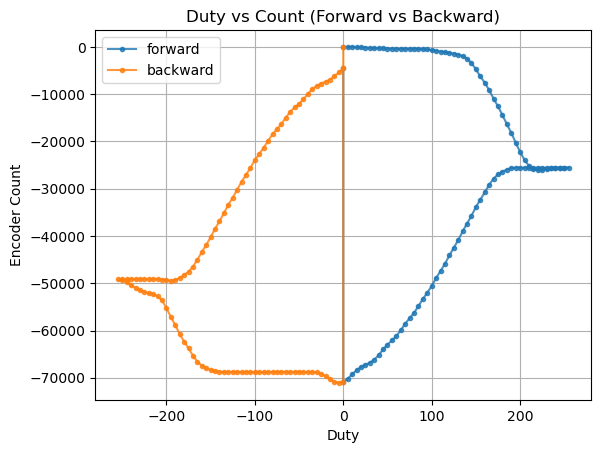

In [ ]:
# split forward/backward
df_forward = df[df["duty"] >= 0]
df_backward = df[df["duty"] <= 0]

plt.figure()

# forward (0 → +max → 0)
plt.plot(df_forward["duty"], df_forward["count"], 
         '.-', label="forward", alpha=0.8)

# backward (0 → -max → 0)
plt.plot(df_backward["duty"], df_backward["count"], 
         '.-', label="backward", alpha=0.8)

plt.xlabel("Duty")
plt.ylabel("Encoder Count")
plt.title("Duty vs Count (Forward vs Backward)")
plt.legend()
plt.grid()